##### **Import packages and read data**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))
from config import DB_PATH, SNAPSHOTS, STATIC_FEATURES, RANDOM_SEED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Kết nối database
conn = sqlite3.connect(DB_PATH)

assessment         = pd.read_sql("SELECT * FROM assessments", conn)
courses            = pd.read_sql("SELECT * FROM courses", conn)
student_info       = pd.read_sql("SELECT * FROM studentInfo", conn)
student_regs       = pd.read_sql("SELECT * FROM studentRegistration", conn)
student_assessment = pd.read_sql("SELECT * FROM studentAssessment", conn)
vle                = pd.read_sql("SELECT * FROM vle", conn)

##### **Assessment data info**

In [3]:
if 'module_presentation_length' not in assessment.columns:
    assessment = assessment.merge(courses, on=['code_module', 'code_presentation'])
assessment


,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
0,AAA,2013J,1752,TMA,19,10.0,268
1,AAA,2013J,1753,TMA,54,20.0,268
2,AAA,2013J,1754,TMA,117,20.0,268
3,AAA,2013J,1755,TMA,166,20.0,268
4,AAA,2013J,1756,TMA,215,30.0,268
...,...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229,0.0,269
202,GGG,2014J,37435,TMA,61,0.0,269
203,GGG,2014J,37436,TMA,124,0.0,269
204,GGG,2014J,37437,TMA,173,0.0,269


In [4]:
assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 206 non-null    object 
 1   code_presentation           206 non-null    object 
 2   id_assessment               206 non-null    int64  
 3   assessment_type             206 non-null    object 
 4   date                        206 non-null    object 
 5   weight                      206 non-null    float64
 6   module_presentation_length  206 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 11.4+ KB


In [5]:
assessment['id_assessment'] = assessment['id_assessment'].astype('object')

**Assessment descriptive statistics**

In [6]:
assessment.describe(include='object').T

,count,unique,top,freq
code_module,206,7,FFF,52
code_presentation,206,4,2014J,57
id_assessment,206,206,1752,1
assessment_type,206,3,TMA,106
date,206,75,222,15


- Dataset gồm 7 module: AAA, BBB, CCC, DDD, EEE, FFF và GGG. Trong đó FFF có nhiều assessment nhất với 52 bài. 

- Về thời điểm học, có 4 presentation: 2013B, 2013J, 2014B và 2014J. `B` tức là module bắt đầu học từ tháng 2, `J` tức là module bắt đầu học từ tháng 10.

- Có 3 loại assessment là: TMA, CMA, Exam. Trong đó TMA chiếm nhiều nhất với 106/206 bài (~51%).

- Có tất cả 206 `id_assessment` đều là duy nhất (unique = 206) → **không có assessment nào bị trùng lặp** trong dataset.

**Modules distribution by bar chart**

Text(0.5, 1.0, 'Distribution of Code Modules')

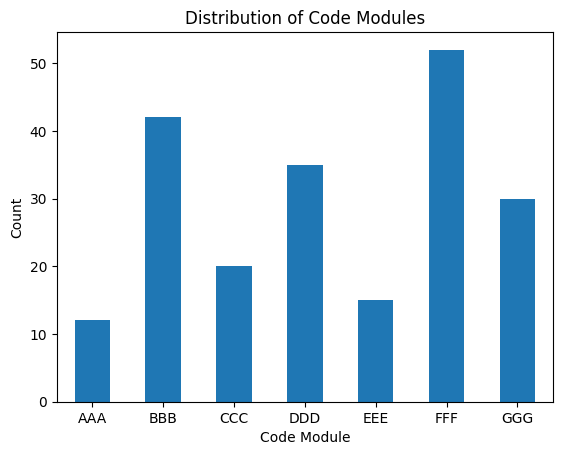

In [7]:
assessment['code_module'].value_counts().sort_index().plot(kind = 'bar', rot = 0)
plt.ylabel('Count')
plt.xlabel('Code Module')
plt.title('Distribution of Code Modules')

**Assessment types percentage by pie chart**

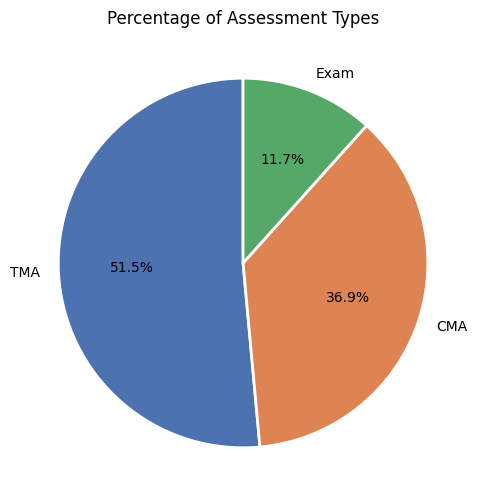

In [8]:
assessment['assessment_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452', '#55A868'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    title='Percentage of Assessment Types',
    figsize=(6, 6)
)

plt.ylabel('')  # ẩn label 'assessment_type' mặc định ở trục y
plt.show()

**Calculate sum of assessment's weight**

In [9]:
assessment[['code_module','code_presentation','weight']].groupby(['code_module','code_presentation']).sum()

weight
code_module code_presentation        
AAA         2013J               200.0
            2014J               200.0
BBB         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
CCC         2014B               300.0
            2014J               300.0
DDD         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
EEE         2013J               200.0
            2014B               200.0
            2014J               200.0
FFF         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
GGG         2013J               100.0
            2014B               100.0
            2014J               100.0

**Detecting anomaly in GGG and CCC weight**

In [10]:
assessment[assessment['code_module'] == 'GGG'].head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
176,GGG,2013J,37418,CMA,229,0.0,261
177,GGG,2013J,37419,CMA,229,0.0,261
178,GGG,2013J,37420,CMA,229,0.0,261
179,GGG,2013J,37421,CMA,229,0.0,261
180,GGG,2013J,37422,CMA,229,0.0,261


In [11]:
assessment[assessment['code_module'] == 'CCC']

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
54,CCC,2014B,24286,CMA,18,2.0,241
55,CCC,2014B,24287,CMA,67,7.0,241
56,CCC,2014B,24288,CMA,137,8.0,241
57,CCC,2014B,24289,CMA,207,8.0,241
58,CCC,2014B,24282,TMA,32,9.0,241
59,CCC,2014B,24283,TMA,102,22.0,241
60,CCC,2014B,24284,TMA,151,22.0,241
61,CCC,2014B,24285,TMA,200,22.0,241
62,CCC,2014B,24290,Exam,?,100.0,241
63,CCC,2014B,40087,Exam,?,100.0,241


- Phần lớn modules (AAA, BBB, DDD, EEE, FFF) có tổng weight = 200, mang tính nhất quán.
- Không phải module nào cũng chạy đủ 4 kỳ (`2013B`, `2013J`, `2014B`, `2014J`) — ví dụ AAA chỉ có `2013J` và `2014J`.

**Điểm bất thường:**

- GGG có tổng weight = 100: tất cả TMA và CMA của GGG đều có `weight = 0.0`, chỉ Exam mới có `weight = 100.0`, nói cách khác, kết quả module phụ thuộc hoàn toàn vào bài kiểm tra cuối kì.

- CCC có tổng weight = 300: module CCC có 2 Exam trong mỗi presentation (mỗi cái `weight = 100`), cộng với TMA+CMA = 100 → tổng = 300.

- Ở module CCC, cột `date` tồn tại giá trị '?' trong các bản ghi có `assignment_types = 'Exam'`

**Checking missing values in `date` column**

In [12]:
assessment[assessment.date == '?']

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
5,AAA,2013J,1757,Exam,?,100.0,268
11,AAA,2014J,1763,Exam,?,100.0,269
23,BBB,2013B,14990,Exam,?,100.0,240
35,BBB,2013J,15002,Exam,?,100.0,268
47,BBB,2014B,15014,Exam,?,100.0,234
53,BBB,2014J,15025,Exam,?,100.0,262
62,CCC,2014B,24290,Exam,?,100.0,241
63,CCC,2014B,40087,Exam,?,100.0,241
72,CCC,2014J,24299,Exam,?,100.0,269
73,CCC,2014J,40088,Exam,?,100.0,269


- `date = '?'` chỉ xuất hiện ở loại `Exam`, không có ở TMA hay CMA → missing có tính hệ thống, không phải ngẫu nhiên.
- 11/24 exam rows bị thiếu ngày, chiếm gần một nửa (~45.8%).
- Mức độ thiếu theo module:
  - AAA, BBB, CCC: thiếu hoàn toàn — không có presentation nào có ngày thi chính xác.
  - DDD: chỉ thiếu 1 presentation (2014J), 3 presentation còn lại có đầy đủ.
  - EEE, FFF, GGG: đầy đủ ngày thi cho tất cả presentations.
- Khả năng cao các module bị thiếu có lịch thi linh hoạt nên không có ngày cố định trong hệ thống.
- Vì Exam thường ở cuối khoá học (ngoài window dự báo), ảnh hưởng thực tế của missing này là **không đáng kể**.


**VLE data extraction**

In [13]:
vle_weekly = pd.read_sql("""
    SELECT 
        sv.id_student,
        sv.code_module,
        sv.code_presentation,
        v.activity_type,
        CAST(FLOOR(CAST(sv.date AS FLOAT) / 7) AS INTEGER) AS week,
        SUM(sv.sum_click) AS weekly_clicks
    FROM studentVle sv
    JOIN vle v 
        ON sv.id_site = v.id_site
        AND sv.code_module = v.code_module
        AND sv.code_presentation = v.code_presentation
    GROUP BY sv.id_student, sv.code_module, sv.code_presentation, v.activity_type, week
""", conn)

In [14]:
vle_weekly.sort_values(['id_student', 'code_module', 'code_presentation', 'week', 'activity_type'], inplace=True)
vle_weekly_agg = (
    vle_weekly
    .groupby(['id_student', 'code_module', 'code_presentation', 'week'], as_index=False)
    .agg(weekly_clicks=('weekly_clicks', 'sum'))
)
vle_weekly_agg


,id_student,code_module,code_presentation,week,weekly_clicks
0,6516,AAA,2014J,-4,110
1,6516,AAA,2014J,-3,48
2,6516,AAA,2014J,-2,2
3,6516,AAA,2014J,-1,96
4,6516,AAA,2014J,0,229
...,...,...,...,...,...
627026,2698588,BBB,2014J,32,13
627027,2698588,BBB,2014J,33,147
627028,2698588,BBB,2014J,34,12
627029,2698588,BBB,2014J,35,7


In [15]:
vle_weekly_agg.describe().apply(lambda x: x.apply('{:.2f}'.format))

,id_student,week,weekly_clicks
count,627031.00,627031.00,627031.00
mean,716245.32,14.06,63.16
std,563638.18,11.02,96.59
min,6516.00,-4.00,1.00
25%,505773.00,4.00,9.00
50%,589295.00,13.00,30.00
75%,645183.00,23.00,78.00
max,2698588.00,38.00,6999.00


- `vle_weekly_agg` gồm **627,031** bản ghi — sau khi gộp `activity_type`, số dòng giảm ~4 lần so với `vle_weekly` (2,518,170), mỗi bản ghi là tổng click của 1 sinh viên trong 1 tuần.

- Cột `week`:
    - Tuần được tính bằng `floor(date / 7)`, tính từ ngày bắt đầu module.
    - Giá trị âm (`min = -4`) cho thấy một số sinh viên đã truy cập VLE trước khi khoá học chính thức bắt đầu.
    - 50% bản ghi nằm trong tuần 4–23, tương ứng giai đoạn giữa khoá học.
    - `max = 38` (~9.5 tháng) phù hợp với độ dài các module trong OULAD (~240–270 ngày).

- Cột `weekly_clicks`:
    - Phân phối lệch phải nặng: median = 30 nhưng mean = 63.16 chứng tỏ dữ liệu bị kéo lên bởi outliers. Trong đó có các outlier cực đoan ví dụ như `max = 6,999` trong khi Q3 = 78.
    - `std = 96.59 > mean = 63.16` cho thấy độ phân tán rất lớn.


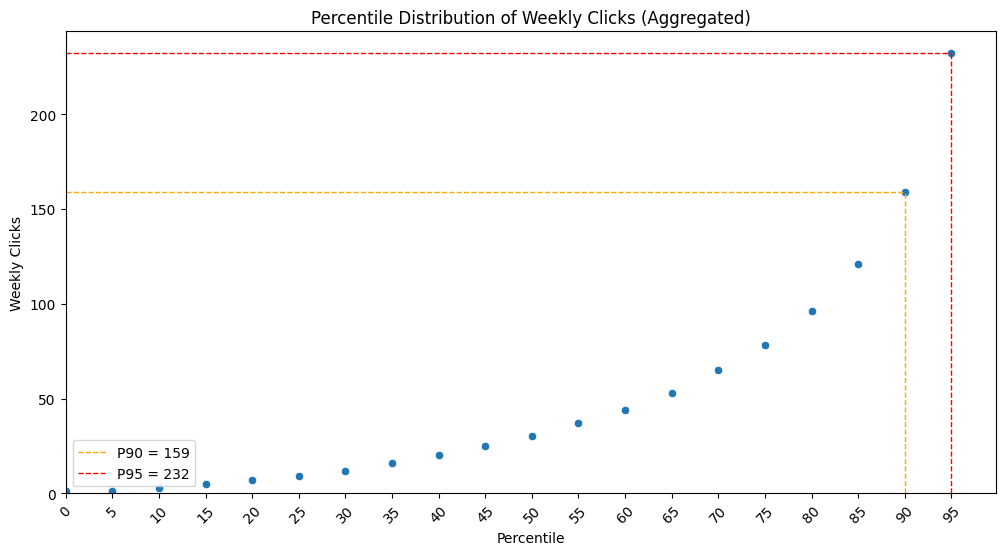

In [16]:
percentiles = range(0, 100, 5)
values = [vle_weekly_agg['weekly_clicks'].quantile(p / 100) for p in percentiles]

p90 = vle_weekly_agg['weekly_clicks'].quantile(0.90)
p95 = vle_weekly_agg['weekly_clicks'].quantile(0.95)

plt.figure(figsize=(12, 6))
sns.scatterplot(x=list(percentiles), y=values)

plt.plot([90, 90], [0, p90], color='orange', linestyle='--', linewidth=1)
plt.plot([0, 90],  [p90, p90], color='orange', linestyle='--', linewidth=1, label=f'P90 = {p90:.0f}')

plt.plot([95, 95], [0, p95], color='red', linestyle='--', linewidth=1)
plt.plot([0, 95],  [p95, p95], color='red', linestyle='--', linewidth=1, label=f'P95 = {p95:.0f}')

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.title('Percentile Distribution of Weekly Clicks (Aggregated)')
plt.xlabel('Percentile')
plt.xticks(range(0, 100, 5), rotation=45)
plt.ylabel('Weekly Clicks')
plt.legend()
plt.show()


- Từ P0 đến P75, weekly_clicks tăng chậm từ 1 đến 80 — phần lớn sinh viên tương tác ở mức vừa phải mỗi tuần.
- Từ P75 trở đi đường cong dốc lên nhanh, dấu hiệu của phân phối lệch phải với đuôi dài.
- P90 = 159, P95 = 232 — 10% sinh viên tích cực nhất có lượng click gấp ~2.5 lần mức trung bình (mean = 63.16).


**Check number of students remaining after every month**

In [17]:
student_regs['date_unregistration'] = pd.to_numeric(
    student_regs['date_unregistration'], errors='coerce'
).astype('float')

In [18]:
from src.features.build_features import build_snapshot_dataset

Hàm `build_snapshot_dataset()` nhằm xây dựng dataset dạng panel cho bài toán dự báo rủi ro học tập sớm. Với mỗi mốc thời gian `T` trong `[30, 60, 90, 120, 150, 180, 210, 240]` ngày, hàm tạo một snapshot thể hiện trạng thái của từng sinh viên tại thời điểm đó.

- **Chuẩn bị (trước loop)**
  - Join `studentAssessment` với `assessments` để lấy deadline, weight, loại bài thi.
  - Tính các cột phái sinh:
    - `days_early`: số ngày nộp sớm (âm = nộp trễ).
    - `is_failed`: 1 nếu điểm < 40, ngược lại 0.
    - `weighted_score`: điểm có trọng số = `score × weight / 100`.
    - Chuyển `date_unregistration` sang số để so sánh với `T`.

- **Trong mỗi vòng lặp tại T**
  - Lọc sinh viên còn active: loại những sinh viên đã rút khỏi khoá trước ngày `T`.
  - VLE features (chỉ lấy dữ liệu đến tuần `T // 7`):
    - `total_clicks`: tổng số click tích luỹ đến T.
    - `active_weeks`: số tuần có tương tác.
    - `avg_weekly_clicks`: click trung bình mỗi tuần.
  - Assessment features (chỉ lấy bài có deadline ≤ T và đã nộp trước T — tránh data leakage):
    - `num_submitted`: số bài đã nộp.
    - `avg_score`: điểm trung bình có trọng số.
    - `avg_days_early`: độ trễ/sớm nộp bài trung bình.
    - `num_failed`: số bài bị trượt (< 40 điểm).
    - `num_due`: số bài đến hạn tính đến T (theo lịch module).
    - `submission_rate`: tỉ lệ nộp bài = `num_submitted / num_due`.
  - Static features: thông tin cá nhân sinh viên (giới tính, vùng, trình độ học vấn, `imd_band`...) và nhãn `final_result`.
  - Merge tất cả lại, gắn biến chỉ mốc thời gian dự đoán `prediction_point = T`.

- **Đầu ra**
  - DataFrame `df_all` gồm 8 snapshot ghép lại — mỗi sinh viên xuất hiện tối đa 8 lần (một lần cho mỗi mốc T còn active), sẵn sàng cho bước huấn luyện model.


In [19]:
final_df = build_snapshot_dataset(conn)
final_df = final_df[[c for c in final_df.columns if c != 'final_result'] + ['final_result']]
final_df

,id_student,code_module,code_presentation,gender,region,age_band,imd_band,highest_education,num_of_prev_attempts,studied_credits,...,date_unregistration,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_days_early,num_failed,avg_score,prediction_point,final_result
0,11391,AAA,2013J,M,East Anglian Region,55<=,90-100%,HE Qualification,0,240,...,NaN,427.0,5.0,85.400000,1.0,1.00,0.0,78.00,30,Pass
1,28400,AAA,2013J,F,Scotland,35-55,20-30%,HE Qualification,0,60,...,NaN,625.0,7.0,89.285714,1.0,-3.00,0.0,70.00,30,Pass
2,31604,AAA,2013J,F,South East Region,35-55,50-60%,A Level or Equivalent,0,60,...,NaN,566.0,7.0,80.857143,1.0,2.00,0.0,72.00,30,Pass
3,32885,AAA,2013J,F,West Midlands Region,0-35,50-60%,Lower Than A Level,0,60,...,NaN,585.0,7.0,83.571429,1.0,-7.00,0.0,69.00,30,Pass
4,38053,AAA,2013J,M,Wales,35-55,80-90%,A Level or Equivalent,0,60,...,NaN,764.0,7.0,109.142857,1.0,0.00,0.0,79.00,30,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178289,2681198,FFF,2014J,M,East Anglian Region,35-55,70-80%,Lower Than A Level,0,90,...,NaN,3926.0,35.0,112.171429,5.0,11.60,1.0,50.50,240,Pass
178290,2682682,FFF,2014J,F,East Midlands Region,0-35,60-70%,A Level or Equivalent,0,120,...,NaN,3530.0,33.0,106.969697,5.0,-2.00,0.0,90.25,240,Distinction
178291,2683857,FFF,2014J,M,South West Region,35-55,70-80%,Lower Than A Level,1,90,...,NaN,8339.0,36.0,231.638889,3.0,1.33,0.0,73.67,240,Pass
178292,2693932,FFF,2014J,M,West Midlands Region,0-35,90-100%,A Level or Equivalent,1,120,...,NaN,2596.0,33.0,78.666667,4.0,3.75,0.0,89.33,240,Pass


In [20]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178294 entries, 0 to 178293
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_student            178294 non-null  int64  
 1   code_module           178294 non-null  object 
 2   code_presentation     178294 non-null  object 
 3   gender                178294 non-null  object 
 4   region                178294 non-null  object 
 5   age_band              178294 non-null  object 
 6   imd_band              178294 non-null  object 
 7   highest_education     178294 non-null  object 
 8   num_of_prev_attempts  178294 non-null  int64  
 9   studied_credits       178294 non-null  int64  
 10  disability            178294 non-null  object 
 11  date_registration     178294 non-null  object 
 12  date_unregistration   16086 non-null   float64
 13  total_clicks          175259 non-null  float64
 14  active_weeks          175259 non-null  float64
 15  

In [21]:
null_df = pd.DataFrame({
    "column": final_df.columns,
    "null_count": final_df.isnull().sum().values,
    "null_percent (%)": (final_df.isnull().sum() / len(final_df) * 100).round(2).values
})

null_df = null_df[null_df["null_count"] > 0].sort_values("null_percent (%)", ascending=False).reset_index(drop=True)

null_df


,column,null_count,null_percent (%)
0,date_unregistration,162208,90.98
1,avg_score,18532,10.39
2,num_submitted,16183,9.08
3,avg_days_early,16183,9.08
4,num_failed,16183,9.08
5,avg_weekly_clicks,3035,1.70
6,total_clicks,3035,1.70
7,active_weeks,3035,1.70


- Tổng quan:
    - Dataset gồm 178,294 dòng và 22 cột, bao gồm thông tin nhân khẩu học, hành vi học tập (VLE), kết quả bài tập và kết quả cuối kỳ.
    - Dataset có đa dạng kiểu dữ liệu: `object` (10 cột), `float64` (10 cột), `int64` (2 cột).

- Phân tích missing values:

    - `date_unregistration` thiếu nhiều nhất (~91.0%) vì phần lớn sinh viên không hủy đăng ký môn học.
    - Các cột VLE (total_clicks, active_weeks, avg_weekly_clicks) thiếu ~1.7%, có thể do sinh viên chưa tương tác hệ thống.
    - Các cột assessment (avg_score, num_submitted,...) thiếu đáng kể (~9-10%), do một số sinh viên chưa nộp bài tại thời điểm prediction_point.


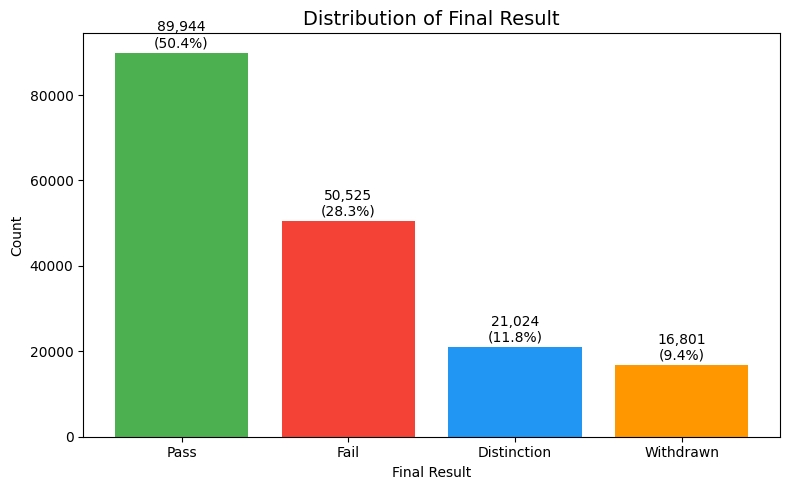

In [22]:
counts = final_df["final_result"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=["#4CAF50", "#F44336", "#2196F3", "#FF9800"])

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}\n({val/len(final_df)*100:.1f}%)",
             ha="center", va="bottom", fontsize=10)

plt.title("Distribution of Final Result", fontsize=14)
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


- Pass chiếm tỷ lệ cao nhất với 89,944 snapshot (50.4%), cho thấy khoảng một nửa sinh viên hoàn thành khóa học ở mức đạt yêu cầu.
- Fail đứng thứ hai với 50,525 snapshot (28.3%) — gần 1/3 sinh viên không qua môn, đây là nhóm quan trọng cần dự đoán sớm.
- Distinction chiếm 11.8% (21,024 snapshot), đây là nhóm sinh viên xuất sắc, chiếm khoảng 19% nhóm sinh viên đạt yêu cầu qua môn.
- Withdrawn chiếm 9.4% (16,801 snapshot), nhóm bỏ học giữa chừng — thường có dấu hiệu sớm qua hành vi tương tác thấp.
- Với bài toán early risk warning, ta có thể gộp Distinction vào nhóm Pass, vì phân loại các sinh viên đạt yêu cầu và các sinh viên xuất sắc thật sự không cần thiết trong bài toán này.

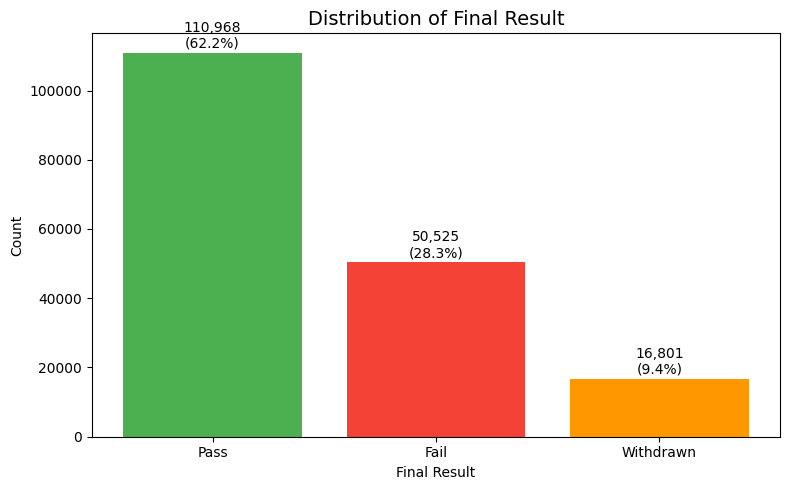

In [23]:
final_df["final_result"] = final_df["final_result"].replace("Distinction", "Pass")

counts = final_df["final_result"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=["#4CAF50", "#F44336", "#FF9800"])

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}\n({val/len(final_df)*100:.1f}%)",
             ha="center", va="bottom", fontsize=10)

plt.title("Distribution of Final Result", fontsize=14)
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Tỷ lệ Pass : Fail : Withdrawn = 62.2% : 28.3% : 9.4% cho thấy dataset có mất cân bằng nhãn ở mức vừa phải

**Train-Test Split**

Sau khi xây dựng xong `final_df`, tập dữ liệu được chia thành tập huấn luyện (train) và tập kiểm tra (test) theo `id_student` — đảm bảo toàn bộ lịch sử của một sinh viên chỉ xuất hiện trong một tập duy nhất. Việc chia theo sinh viên thay vì theo hàng giúp ngăn chặn việc mô hình "học" thông tin từ các snapshot khác nhau của cùng một người trong quá trình huấn luyện, từ đó tránh data leakage.

Tỉ lệ chia 80/20, cố định `random_state=42` để đảm bảo tái lập kết quả.


In [24]:
from sklearn.model_selection import train_test_split

def splitting(df):
    train_ids, test_ids = train_test_split(
        df['id_student'].unique(),
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    train_df = df[df['id_student'].isin(train_ids)].reset_index(drop=True)
    test_df  = df[df['id_student'].isin(test_ids)].reset_index(drop=True)

    print(f"Train: {train_df['id_student'].nunique():,} students, {len(train_df):,} rows")
    print(f"Test:  {test_df['id_student'].nunique():,} students, {len(test_df):,} rows")
    return train_df, test_df

train, test = splitting(final_df)

Train: 17,921 students, 142,384 rows
Test:  4,481 students, 35,910 rows


Tập train gồm 17,921 sinh viên với 142,384 snapshot, tập test gồm 4,481 sinh viên với 35,910 snapshot — tỉ lệ xấp xỉ 80/20. 

In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142384 entries, 0 to 142383
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_student            142384 non-null  int64  
 1   code_module           142384 non-null  object 
 2   code_presentation     142384 non-null  object 
 3   gender                142384 non-null  object 
 4   region                142384 non-null  object 
 5   age_band              142384 non-null  object 
 6   imd_band              142384 non-null  object 
 7   highest_education     142384 non-null  object 
 8   num_of_prev_attempts  142384 non-null  int64  
 9   studied_credits       142384 non-null  int64  
 10  disability            142384 non-null  object 
 11  date_registration     142384 non-null  object 
 12  date_unregistration   12920 non-null   float64
 13  total_clicks          139934 non-null  float64
 14  active_weeks          139934 non-null  float64
 15  

**Question marks in columns**

In [26]:
# Tìm các cột có chứa dấu '?'
cols_with_question = [col for col in train.columns if (train[col] == '?').any()]

print(f"Số cột có dấu '?': {len(cols_with_question)}")
print(f"Các cột có dấu '?': {cols_with_question}")

Số cột có dấu '?': 2
Các cột có dấu '?': ['imd_band', 'date_registration']


In [27]:
print(f"Số lượng missing value ở cột imd_band: {len(train[train['imd_band'] == '?'])}")
print(f"Tỉ lệ missing value ở cột imd_band: {len(train[train['imd_band'] == '?']) / len(train) * 100:.2f}%")

Số lượng missing value ở cột imd_band: 5986
Tỉ lệ missing value ở cột imd_band: 4.20%


##### **EDA on static features**

In [28]:
static_cols = ['id_student'] + STATIC_FEATURES + ['final_result']
unique_students = train[static_cols].drop_duplicates(subset='id_student')

In [29]:
unique_students['imd_band'].value_counts()

imd_band
30-40%     1925
20-30%     1904
40-50%     1804
10-20      1803
50-60%     1741
0-10%      1686
70-80%     1668
60-70%     1620
80-90%     1556
90-100%    1494
?           720
Name: count, dtype: int64

In [30]:
# Tỷ lệ % region theo từng imd_band + count
result = (
    unique_students.groupby(['imd_band', 'region'])
    .size()
    .reset_index(name='count')
)

result['percent'] = (
    result.groupby('imd_band')['count']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

print(result[result['imd_band'] == '?'].sort_values('count', ascending=False).to_string(index=False))

imd_band               region  count  percent
       ?         North Region    467    64.86
       ?              Ireland    183    25.42
       ?         South Region     35     4.86
       ? West Midlands Region     25     3.47
       ?             Scotland      4     0.56
       ?    South West Region      3     0.42
       ?     Yorkshire Region      2     0.28
       ? North Western Region      1     0.14


Giá trị `?` trong `imd_band` tập trung gần như hoàn toàn ở hai vùng: North Region (64.86%) và Ireland (25.42%) — cộng lại chiếm ~90.3% tổng số missing. Các vùng còn lại chỉ đóng góp ~9.7%.


In [31]:
imd_by_region = (
    pd.crosstab(unique_students['region'], unique_students['imd_band'], normalize='index') * 100
).round(2)

imd_by_region = imd_by_region.sort_values('?', ascending=False)

display(
    imd_by_region.style
    .format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
    .set_caption("Phân phối imd_band (%) theo Region")
    .set_table_styles([
        {'selector': 'caption',  'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'table',    'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-size', '14px')]},
        {'selector': 'th, td',   'props': [('padding', '8px 14px'), ('text-align', 'center')]},
        {'selector': '',         'props': [('overflow-y', 'auto'), ('max-height', '500px'), ('display', 'block')]},
    ])
)


imd_band,0-10%,10-20,20-30%,30-40%,40-50%,50-60%,60-70%,70-80%,80-90%,90-100%,?
region,,,,,,,,,,,
North Region,8.11%,10.85%,6.74%,5.96%,5.87%,3.71%,3.52%,4.69%,4.50%,0.39%,45.65%
Ireland,9.72%,10.10%,6.91%,7.80%,5.75%,8.82%,7.80%,6.65%,6.65%,6.39%,23.40%
South Region,1.05%,4.50%,5.73%,6.55%,10.93%,10.40%,8.88%,12.62%,15.55%,21.74%,2.05%
West Midlands Region,17.52%,14.43%,11.03%,8.99%,10.35%,7.48%,8.61%,8.99%,5.74%,4.98%,1.89%
South West Region,3.99%,7.29%,10.74%,15.57%,12.65%,12.19%,10.20%,12.58%,7.90%,6.67%,0.23%
Yorkshire Region,19.42%,12.21%,12.31%,10.48%,9.62%,9.62%,7.31%,10.48%,5.00%,3.37%,0.19%
Scotland,8.14%,7.76%,10.29%,11.27%,10.80%,12.21%,10.38%,9.49%,9.92%,9.54%,0.19%
North Western Region,23.09%,12.23%,13.46%,12.23%,7.79%,7.72%,7.10%,7.31%,5.67%,3.35%,0.07%
East Anglian Region,3.25%,4.60%,8.36%,10.38%,12.17%,11.33%,12.06%,12.73%,11.89%,13.24%,0.00%


- **North Region** (42.87%) và **Ireland** (23.28%) có tỷ lệ `?` vượt trội so với tất cả các vùng còn lại (đều dưới 2%). Ireland là vùng duy nhất có phân phối non-missing gần như đồng đều qua tất cả các band (~6–10%).

- **North Western** (0-10%: 23.68%), **Yorkshire** (0-10%: 19.55%), **West Midlands** (0-10%: 18.68%) là các vùng có chỉ số imd mức thấp nhất chiếm tỉ trọng cao nhất. **London** (10-20%: 20.72%, 20-30%: 17.87%) và **Wales** (20-30%: 13.38%) cũng có mức độ tập trung cao ở các mức imd thấp.

- **South Region** (90-100%: 21.35%, 80-90%: 15.59%) và **South East Region** (60-70%: 13.78%, 90-100%: 12.50%) tập trung ở các band cao. **East Anglian Region** có xu hướng tương tự, với các band từ 40% trở lên dao động 11–13%.

- **Scotland**, **East Midlands** và **South West Region** không lệch rõ về phía nào, các band dao động tương đối đều trong khoảng 7–13%.

In [32]:
imd_by_edu = (
    pd.crosstab(unique_students['highest_education'], unique_students['imd_band'], normalize='index') * 100
).round(2)

imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', '?']

edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

imd_by_edu = imd_by_edu.reindex(edu_order).reindex(columns=imd_order)

display(
    imd_by_edu.style
    .format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
    .set_caption("Phân phối IMD Band (%) theo Highest Education")
    .set_table_styles([
        {'selector': 'caption',  'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'table',    'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-size', '14px')]},
        {'selector': 'th, td',   'props': [('padding', '8px 14px'), ('text-align', 'center')]},
        {'selector': '',         'props': [('overflow-y', 'auto'), ('max-height', '500px'), ('display', 'block')]},
    ])
)

imd_band,0-10%,10-20,20-30%,30-40%,40-50%,50-60%,60-70%,70-80%,80-90%,90-100%,?
highest_education,,,,,,,,,,,
No Formal quals,18.75%,16.25%,22.50%,18.12%,1.88%,5.00%,5.62%,1.25%,0.00%,1.25%,9.38%
Lower Than A Level,11.43%,11.37%,11.55%,10.70%,10.05%,9.56%,8.59%,8.67%,7.95%,6.39%,3.72%
A Level or Equivalent,8.72%,9.90%,9.97%,10.89%,10.65%,10.16%,9.62%,10.02%,8.93%,8.80%,2.34%
HE Qualification,6.65%,7.45%,9.86%,10.60%,9.48%,9.48%,8.92%,9.76%,10.18%,10.95%,6.68%
Post Graduate Qualification,0.00%,4.35%,6.52%,1.63%,1.63%,3.80%,4.89%,1.63%,8.70%,25.00%,41.85%


- **No Formal quals** tập trung mạnh ở các band thấp: 20-30% (20.81%), 10-20% (19.29%), 30-40% (17.77%), 0-10% (17.26%) — gần như không xuất hiện ở band 80-90% (0.00%). Tỷ lệ `?` = 7.11%, cao thứ hai trong bảng.
- **Lower Than A Level** giảm dần từ band thấp đến band cao: từ 11.75% (0-10%) xuống 6.39% (90-100%), không có band nào chiếm ưu thế rõ rệt. Tỷ lệ `?` = 3.10%.
- **A Level or Equivalent** phân phối tương đối đồng đều qua tất cả các band (8–11%), không lệch rõ về phía nào. Tỷ lệ `?` = 2.22%.
- **HE Qualification** có xu hướng ngược với No Formal quals — band thấp (0-10%: 6.63%) thấp hơn band cao (90-100%: 11.33%). Tỷ lệ `?` = 6.39%, cao bất thường so với Lower Than A Level (3.10%) và A Level (2.22%).
- **Post Graduate Qualification** có tỷ lệ `?` cao nhất (41.80%), gần như không có sinh viên ở band 0-10% (0.00%), trong khi tập trung rõ nhất ở band 90-100% (25.93%). 

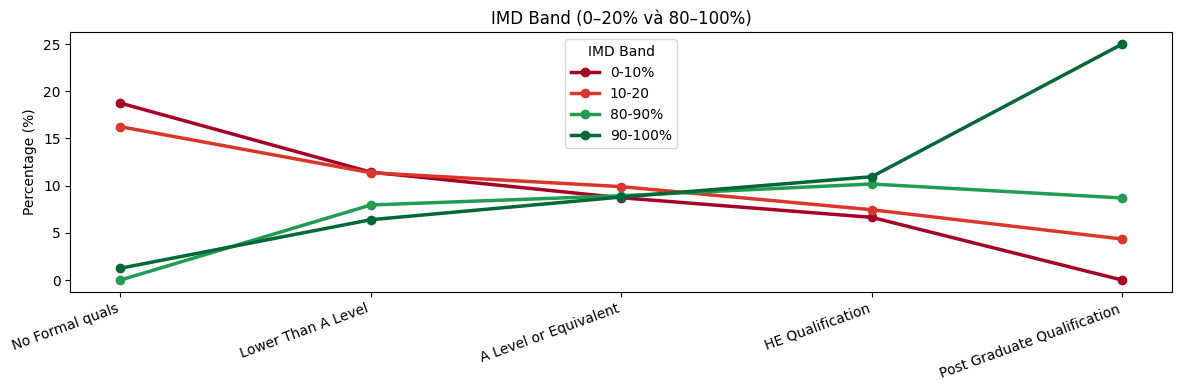

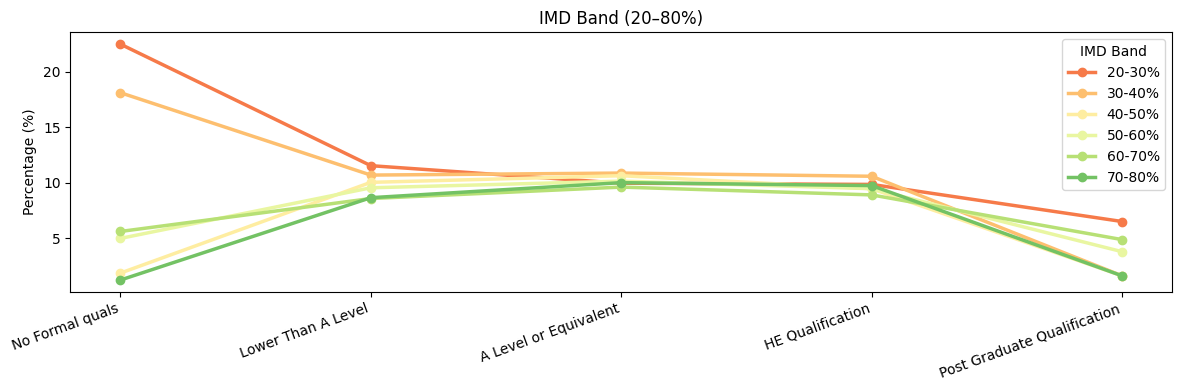

In [33]:
edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

all_bands    = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%',
                '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
extreme_bands = ['0-10%', '10-20', '80-90%', '90-100%']
middle_bands  = ['20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%']

cmap   = plt.cm.RdYlGn
colors = {band: cmap(i / (len(all_bands) - 1)) for i, band in enumerate(all_bands)}

imd_by_edu = (
    pd.crosstab(unique_students['highest_education'], unique_students['imd_band'], normalize='index') * 100
).reindex(edu_order)

# Plot 1 — 4 band đầu và cuối
plt.figure(figsize=(12, 4))
for imd in extreme_bands:
    plt.plot(edu_order, imd_by_edu[imd], marker='o', label=imd, color=colors[imd], linewidth=2.5)
plt.xticks(range(len(edu_order)), edu_order, rotation=20, ha='right')
plt.ylabel('Percentage (%)')
plt.title('IMD Band (0–20% và 80–100%)')
plt.legend(title='IMD Band')
plt.tight_layout()
plt.show()

# Plot 2 — 6 band giữa
plt.figure(figsize=(12, 4))
for imd in middle_bands:
    plt.plot(edu_order, imd_by_edu[imd], marker='o', label=imd, color=colors[imd], linewidth=2.5)
plt.xticks(range(len(edu_order)), edu_order, rotation=20, ha='right')
plt.ylabel('Percentage (%)')
plt.title('IMD Band (20–80%)')
plt.legend(title='IMD Band')
plt.tight_layout()
plt.show()

**Plot 1 — Band cực trị (0–20% và 80–100%):**
- Xu thế nghịch biến rõ ràng ở 2 band thấp: 0-10% giảm từ ~17.3% xuống ~0%, 10-20% giảm từ ~19.3% xuống ~3.9% khi học vấn tăng dần.
- Xu thế thuận biến ở 90-100%: tăng dần từ ~1.5% đến ~11.3% (HE Qualification), sau đó tăng đột biến lên ~25.9% ở Post Graduate Qualification.
- 80-90% tăng nhẹ và ổn định từ ~0% lên ~10.3% (HE Qualification), sau đó giảm nhẹ về ~9% ở Post Graduate — không có bước nhảy đột ngột như 90-100%.
- Cả 4 đường hội tụ quanh mức ~8.5–10.5% tại A Level or Equivalent — đây là điểm giao nhau của hai xu thế ngược chiều.

**Plot 2 — Band giữa (20–80%):**
- 20-30% và 30-40% có xu thế giảm tương tự hai band thấp ở Plot 1: lần lượt từ ~20.8% và ~17.8% xuống ~5.3% và ~1.1% ở Post Graduate Qualification.
- 40-50%, 50-60%, 60-70% và 70-80% có dạng hình vòm — tăng từ No Formal quals đến A Level or Equivalent, sau đó giảm dần về Post Graduate Qualification.
- Tất cả 6 đường hội tụ vào vùng 9–11% tại A Level or Equivalent và HE Qualification — phân phối đồng đều nhất ở hai mức học vấn này.
- Post Graduate Qualification là điểm bất thường: hầu hết các band đều giảm mạnh tại đây, trong khi 90-100% (Plot 1) lại tăng vọt.

In [34]:
unique_students.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17921 entries, 0 to 19986
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_student            17921 non-null  int64 
 1   gender                17921 non-null  object
 2   region                17921 non-null  object
 3   age_band              17921 non-null  object
 4   imd_band              17921 non-null  object
 5   highest_education     17921 non-null  object
 6   num_of_prev_attempts  17921 non-null  int64 
 7   studied_credits       17921 non-null  int64 
 8   disability            17921 non-null  object
 9   final_result          17921 non-null  object
dtypes: int64(3), object(7)
memory usage: 1.5+ MB


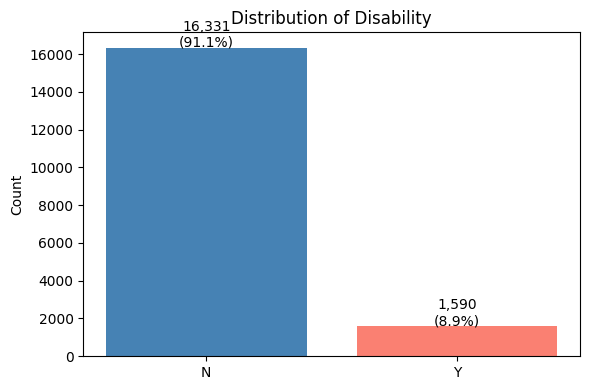

In [35]:
counts = unique_students['disability'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=['steelblue', 'salmon'])
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, f"{v:,}\n({v/len(unique_students)*100:.1f}%)", ha='center')
plt.title('Distribution of Disability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [36]:
disabled_students = unique_students[unique_students['disability'] == 'Y']

result = (
    disabled_students['imd_band']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
result.columns = ['imd_band', 'disability percentage (%)']
result

,imd_band,disability percentage (%)
0,20-30%,13.40
1,10-20,12.70
2,0-10%,12.45
3,40-50%,11.82
4,30-40%,11.32
5,50-60%,8.36
6,60-70%,8.30
7,90-100%,7.42
8,70-80%,7.17
9,80-90%,5.72


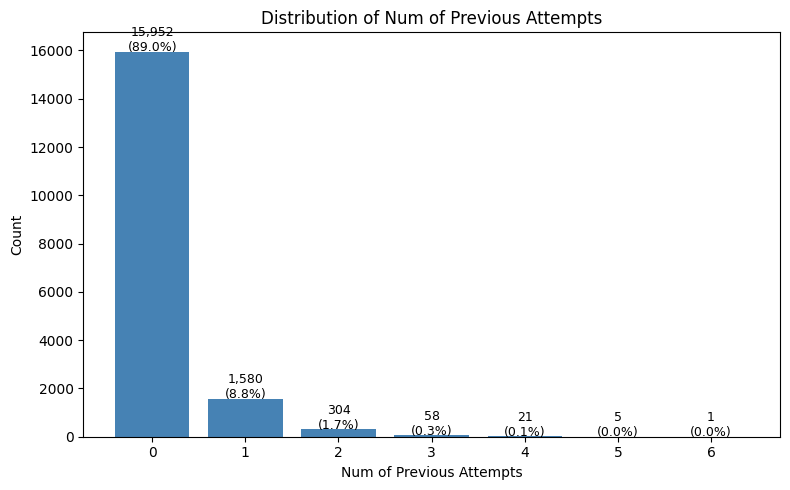

In [37]:
counts = unique_students['num_of_prev_attempts'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='steelblue')
for i, (idx, v) in enumerate(counts.items()):
    plt.text(idx, v + 20, f"{v:,}\n({v/len(unique_students)*100:.1f}%)", ha='center', fontsize=9)
plt.xlabel('Num of Previous Attempts')
plt.ylabel('Count')
plt.title('Distribution of Num of Previous Attempts')
plt.xticks(counts.index)
plt.tight_layout()
plt.show()

In [38]:
unique_students['is_retake_the_course'] = unique_students['num_of_prev_attempts'].apply(
    lambda x: 1 if x > 0 else x
)

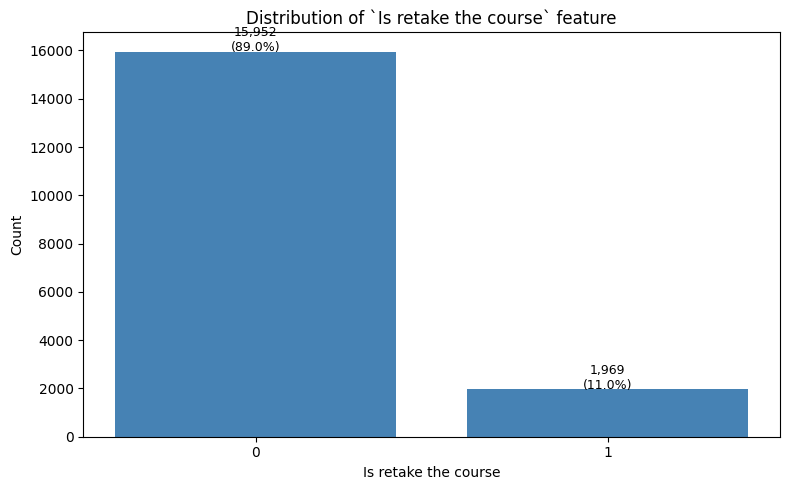

In [39]:
counts = unique_students['is_retake_the_course'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='steelblue')
for i, (idx, v) in enumerate(counts.items()):
    plt.text(idx, v + 20, f"{v:,}\n({v/len(unique_students)*100:.1f}%)", ha='center', fontsize=9)
plt.xlabel('Is retake the course')
plt.ylabel('Count')
plt.title('Distribution of `Is retake the course` feature')
plt.xticks(counts.index)
plt.tight_layout()
plt.show()

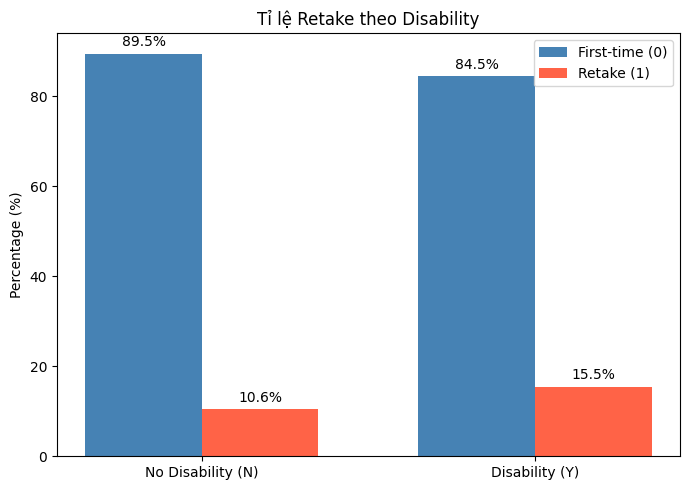

In [40]:
retake_disability = (
    pd.crosstab(unique_students['disability'], unique_students['is_retake_the_course'], normalize='index') * 100
).round(2)

x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars0 = ax.bar(x - width/2, retake_disability.loc[['N', 'Y'], 0], width, label='First-time (0)', color='steelblue')
bars1 = ax.bar(x + width/2, retake_disability.loc[['N', 'Y'], 1], width, label='Retake (1)', color='tomato')
ax.bar_label(bars0, fmt='%.1f%%', padding=3)
ax.bar_label(bars1, fmt='%.1f%%', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(['No Disability (N)', 'Disability (Y)'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Tỉ lệ Retake theo Disability')
ax.legend()
plt.tight_layout()
plt.show()

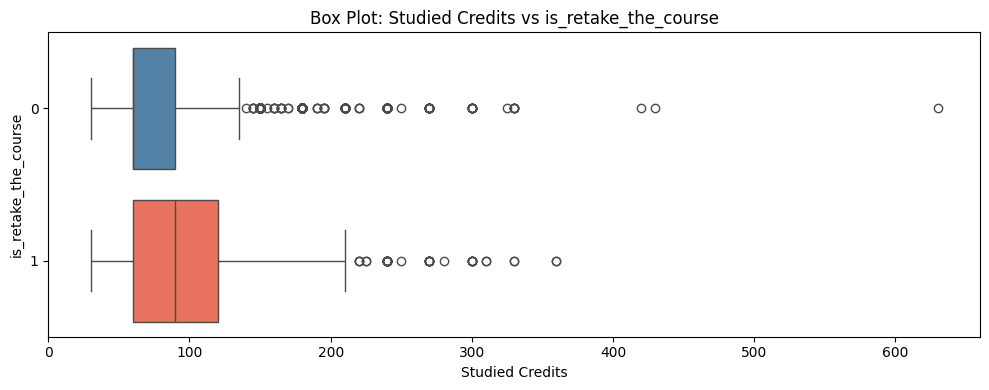

In [41]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=unique_students,
    x='studied_credits',
    y='is_retake_the_course',
    orient='h',
    palette=['steelblue', 'tomato']
)
plt.xlabel('Studied Credits')
plt.ylabel('is_retake_the_course')
plt.title('Box Plot: Studied Credits vs is_retake_the_course')
plt.tight_layout()
plt.show()

In [42]:
unique_students.groupby('is_retake_the_course')['studied_credits'].describe()

,count,mean,std,min,25%,50%,75%,max
is_retake_the_course,,,,,,,,
0,15952.0,77.742289,35.096269,30.0,60.0,60.0,90.0,630.0
1,1969.0,102.717115,48.585497,30.0,60.0,90.0,120.0,360.0


##### **Target-based EDA**

In [43]:
unique_students['disability'] = unique_students['disability'].apply(lambda x: 1 if x == 'Y' else 0)
unique_students['is_U35'] = unique_students['age_band'].apply(lambda x: 1 if x == '0-35' else 0)

In [44]:
unique_students.groupby('final_result')[['is_retake_the_course', 'studied_credits', 'num_of_prev_attempts', 
                                         'disability', 'is_U35']].mean()

,is_retake_the_course,studied_credits,num_of_prev_attempts,disability,is_U35
final_result,,,,,
Fail,0.159462,80.545876,0.210631,0.090207,0.751875
Pass,0.084357,78.452949,0.101817,0.072175,0.672724
Withdrawn,0.117364,86.074661,0.146776,0.132919,0.713235


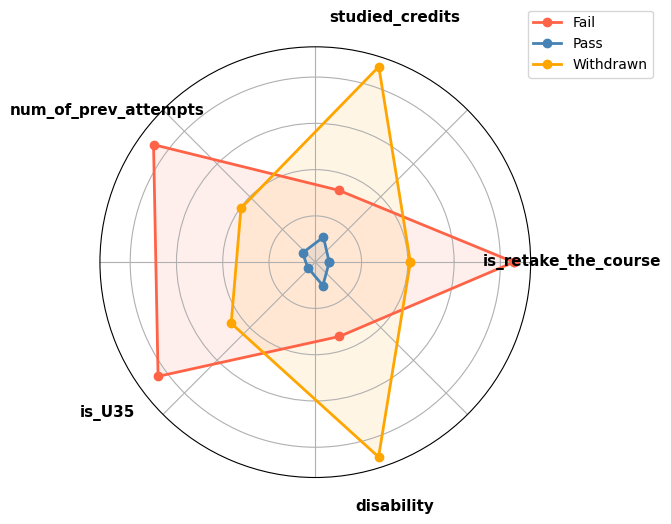

In [45]:
def plot_radar(df, categories, group_col, groups=None, colors=None):
    if groups is None:
        groups = df[group_col].unique().tolist()
    if colors is None:
        colors = ['tomato', 'steelblue', 'orange', 'green', 'purple'][:len(groups)]

    df_encoded = df.copy()
    for col in categories:
        if df_encoded[col].dtype == 'object':
            df_encoded[col] = (df_encoded[col] == 'Y').astype(int)

    data = df_encoded.groupby(group_col)[categories].mean()

    # Z-score — thêm epsilon tránh chia 0
    data_norm = (data - data.mean()) / (data.std() + 1e-8)
    data_norm = data_norm.fillna(0)
    data_norm = data_norm - data_norm.min().min() + 0.1

    max_val = data_norm.values.max()

    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for group, color in zip(groups, colors):
        values = data_norm.loc[group].tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=group, color=color)
        ax.fill(angles, values, alpha=0.1, color=color)

    ax.set_xticklabels([])
    for angle, label in zip(angles[:-1], categories):
        ax.text(angle, max_val * 1.25, label,
                ha='center', va='center', fontsize=11, fontweight='bold')

    ax.set_yticklabels([])
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

plot_radar(
    df=unique_students,
    categories=['is_retake_the_course', 'studied_credits', 'num_of_prev_attempts', 'is_U35', 'disability'],
    group_col='final_result',
    groups=['Fail', 'Pass', 'Withdrawn'],
    colors=['tomato', 'steelblue', 'orange']
)

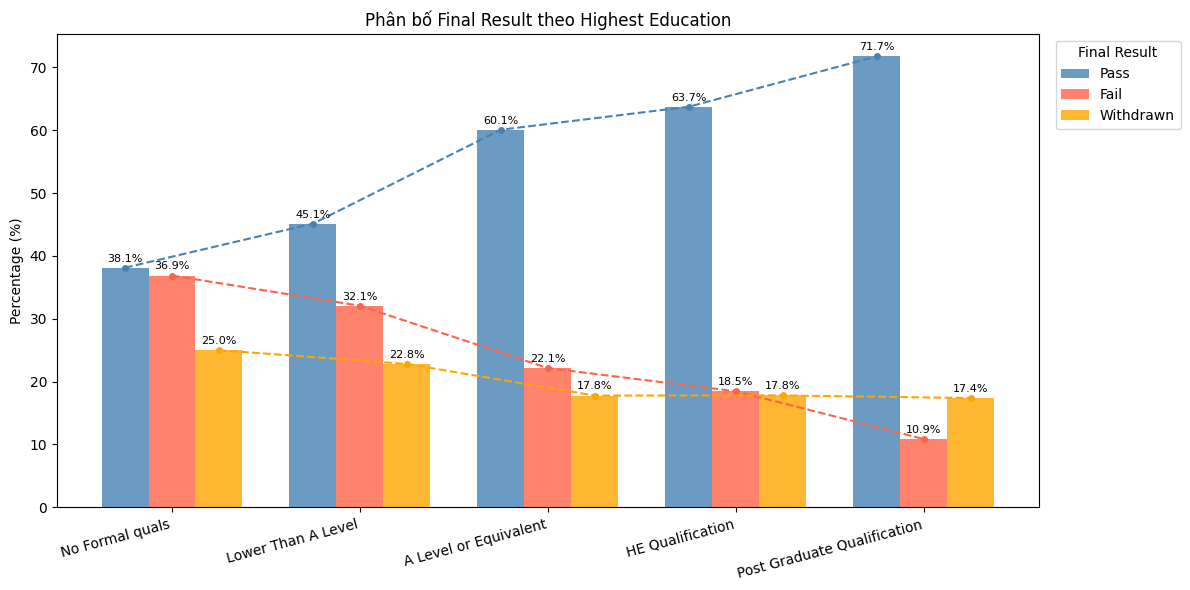

In [46]:
edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

result_order = ['Pass', 'Fail', 'Withdrawn']
colors = ['steelblue', 'tomato', 'orange']

plot_data = (
    pd.crosstab(unique_students['highest_education'], unique_students['final_result'], normalize='index') * 100
)[result_order].reindex(edu_order)

x = np.arange(len(edu_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (result, color) in enumerate(zip(result_order, colors)):
    bars = ax.bar(x + i * width - width, plot_data[result], width, label=result, color=color, alpha=0.8)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
    # Trend line
    ax.plot(x + i * width - width, plot_data[result], 'o--', color=color, linewidth=1.5, markersize=4)

ax.set_xticks(x)
ax.set_xticklabels(edu_order, rotation=15, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Phân bố Final Result theo Highest Education')
ax.legend(title='Final Result', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

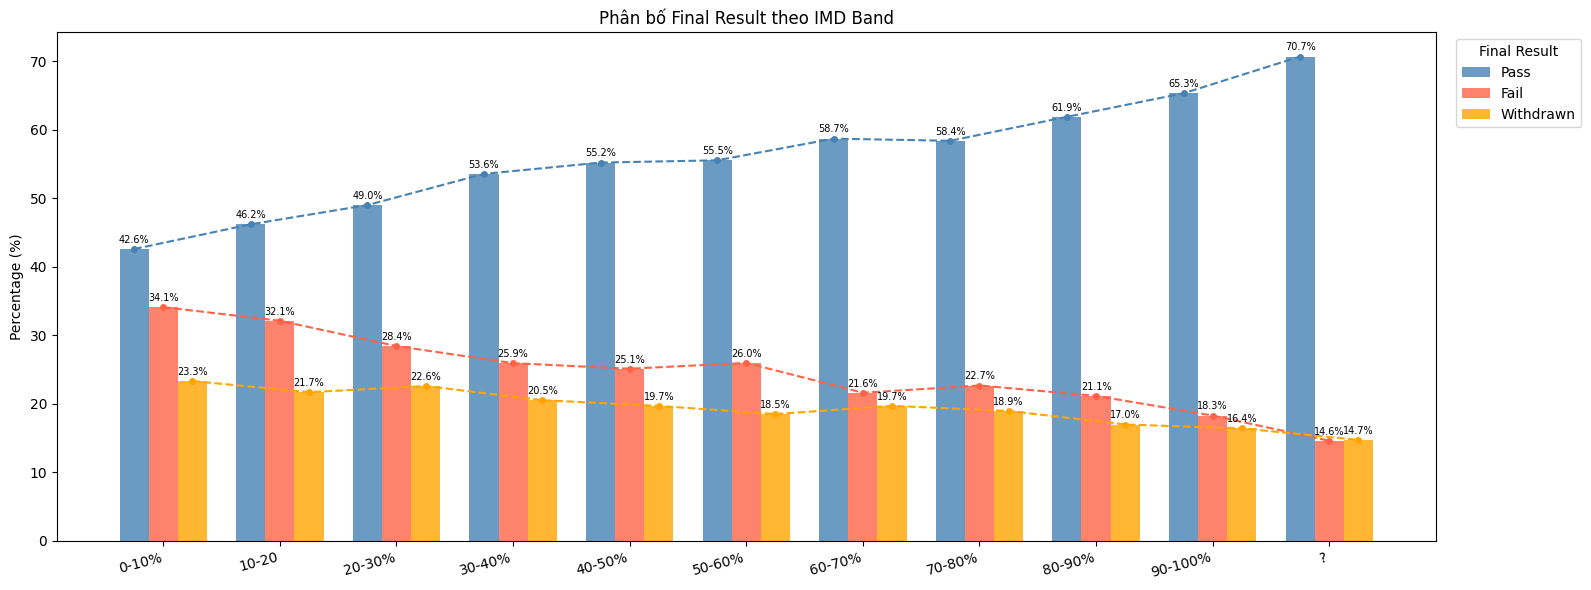

In [47]:
imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%',
             '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', '?']

result_order = ['Pass', 'Fail', 'Withdrawn']
colors = ['steelblue', 'tomato', 'orange']

plot_data = (
    pd.crosstab(unique_students['imd_band'], unique_students['final_result'], normalize='index') * 100
)[result_order].reindex(imd_order)

x = np.arange(len(imd_order))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

for i, (result, color) in enumerate(zip(result_order, colors)):
    bars = ax.bar(x + i * width - width, plot_data[result], width, label=result, color=color, alpha=0.8)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=7)
    ax.plot(x + i * width - width, plot_data[result], 'o--', color=color, linewidth=1.5, markersize=4)

ax.set_xticks(x)
ax.set_xticklabels(imd_order, rotation=15, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Phân bố Final Result theo IMD Band')
ax.legend(title='Final Result', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### **EDA on dynamic features**

In [48]:
dynamic_features = [
    'total_clicks',
    'active_weeks',
    'avg_weekly_clicks',
    'num_submitted',
    'avg_score',
    'num_failed',
    'avg_days_early',
]

id_cols = ['id_student', 'code_module', 'code_presentation', 'prediction_point']

dynamic_df = train[id_cols + dynamic_features + ['final_result']].copy()

dynamic_df.head()

,id_student,code_module,code_presentation,prediction_point,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_score,num_failed,avg_days_early,final_result
0,11391,AAA,2013J,30,427.0,5.0,85.400000,1.0,78.0,0.0,1.0,Pass
1,28400,AAA,2013J,30,625.0,7.0,89.285714,1.0,70.0,0.0,-3.0,Pass
2,31604,AAA,2013J,30,566.0,7.0,80.857143,1.0,72.0,0.0,2.0,Pass
3,38053,AAA,2013J,30,764.0,7.0,109.142857,1.0,79.0,0.0,0.0,Pass
4,45462,AAA,2013J,30,610.0,6.0,101.666667,1.0,70.0,0.0,-1.0,Pass


In [49]:
dynamic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142384 entries, 0 to 142383
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_student         142384 non-null  int64  
 1   code_module        142384 non-null  object 
 2   code_presentation  142384 non-null  object 
 3   prediction_point   142384 non-null  int64  
 4   total_clicks       139934 non-null  float64
 5   active_weeks       139934 non-null  float64
 6   avg_weekly_clicks  139934 non-null  float64
 7   num_submitted      129388 non-null  float64
 8   avg_score          127544 non-null  float64
 9   num_failed         129388 non-null  float64
 10  avg_days_early     129388 non-null  float64
 11  final_result       142384 non-null  object 
dtypes: float64(7), int64(2), object(3)
memory usage: 13.0+ MB


In [50]:
dynamic_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_student,142384.0,709006.399223,563054.520854,8462.0,498455.000000,585074.000000,640752.000000,2710343.0
prediction_point,142384.0,130.209996,68.868787,30.0,60.000000,120.000000,180.000000,240.0
total_clicks,139934.0,1072.269320,1358.444418,1.0,269.000000,617.000000,1334.000000,23115.0
active_weeks,139934.0,15.646984,9.213184,1.0,8.000000,14.000000,22.000000,39.0
avg_weekly_clicks,139934.0,60.742622,56.398596,1.0,25.444444,44.085145,76.921474,1070.5
num_submitted,129388.0,3.809596,2.684697,1.0,2.000000,3.000000,5.000000,14.0
avg_score,127544.0,73.540556,15.513499,0.0,64.730000,76.000000,85.000000,100.0
num_failed,129388.0,0.163323,0.494247,0.0,0.000000,0.000000,0.000000,8.0
avg_days_early,129388.0,0.936219,8.099832,-123.0,-1.500000,0.000000,1.500000,236.0


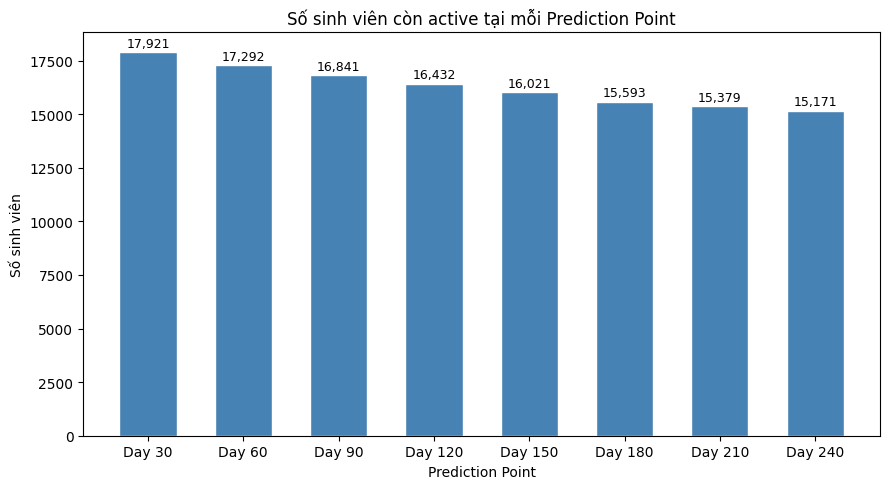

In [51]:
students_per_point = (
    dynamic_df.groupby('prediction_point')['id_student']
    .nunique()
    .reset_index(name='num_students')
)

plt.figure(figsize=(9, 5))
bars = plt.bar(
    students_per_point['prediction_point'],
    students_per_point['num_students'],
    width=18, color='steelblue', edgecolor='white'
)

for bar, val in zip(bars, students_per_point['num_students']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.xticks(SNAPSHOTS, [f'Day {t}' for t in SNAPSHOTS])
plt.xlabel('Prediction Point')
plt.ylabel('Số sinh viên')
plt.title('Số sinh viên còn active tại mỗi Prediction Point')
plt.tight_layout()
plt.show()

In [52]:
students_per_point['delta'] = students_per_point['num_students'].diff().astype('Int64')

prev = students_per_point['prediction_point'].shift(1).astype('Int64')
students_per_point['interval'] = prev.combine(
    students_per_point['prediction_point'],
    lambda a, b: f'Day {a} → Day {b}' if pd.notna(a) else None
)

delta_df = students_per_point.dropna(subset=['delta']).copy()

# Delta lớn nhất / nhỏ nhất (theo abs)
max_row = delta_df.loc[delta_df['delta'].abs().idxmax()]
min_row = delta_df.loc[delta_df['delta'].abs().idxmin()]

print("=" * 45)
print(f"Delta lớn nhất : {max_row['delta']:>6,}  ({max_row['interval']})")
print(f"Delta nhỏ nhất : {min_row['delta']:>6,}  ({min_row['interval']})")
print(f"Trung bình delta: {delta_df['delta'].mean():.1f} sinh viên/30 ngày")
print("=" * 45)

delta_df[['interval', 'num_students', 'delta']]

Delta lớn nhất :   -629  (Day 30 → Day 60)
Delta nhỏ nhất :   -208  (Day 210 → Day 240)
Trung bình delta: -392.9 sinh viên/30 ngày


,interval,num_students,delta
1,Day 30 → Day 60,17292,-629
2,Day 60 → Day 90,16841,-451
3,Day 90 → Day 120,16432,-409
4,Day 120 → Day 150,16021,-411
5,Day 150 → Day 180,15593,-428
6,Day 180 → Day 210,15379,-214
7,Day 210 → Day 240,15171,-208


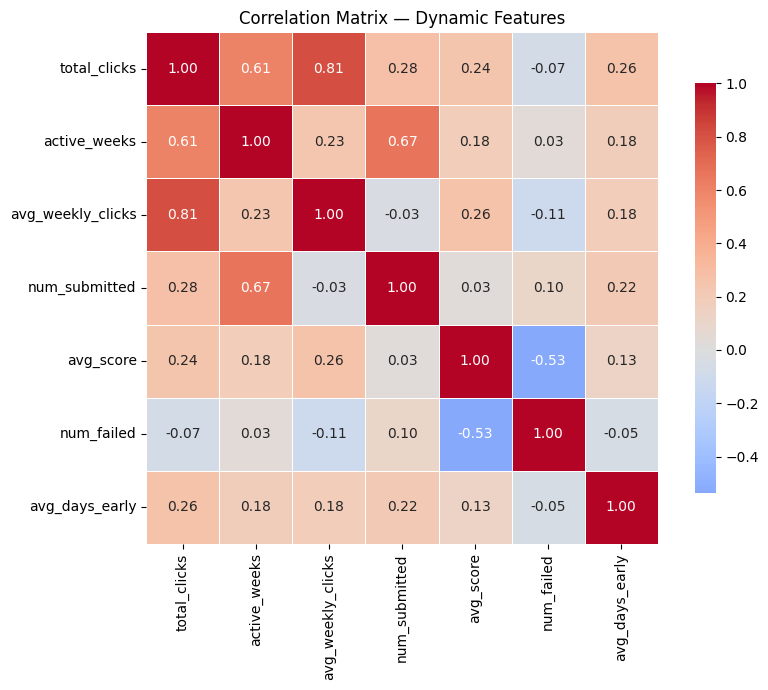

In [53]:
corr = dynamic_df[dynamic_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — Dynamic Features')
plt.tight_layout()
plt.show()

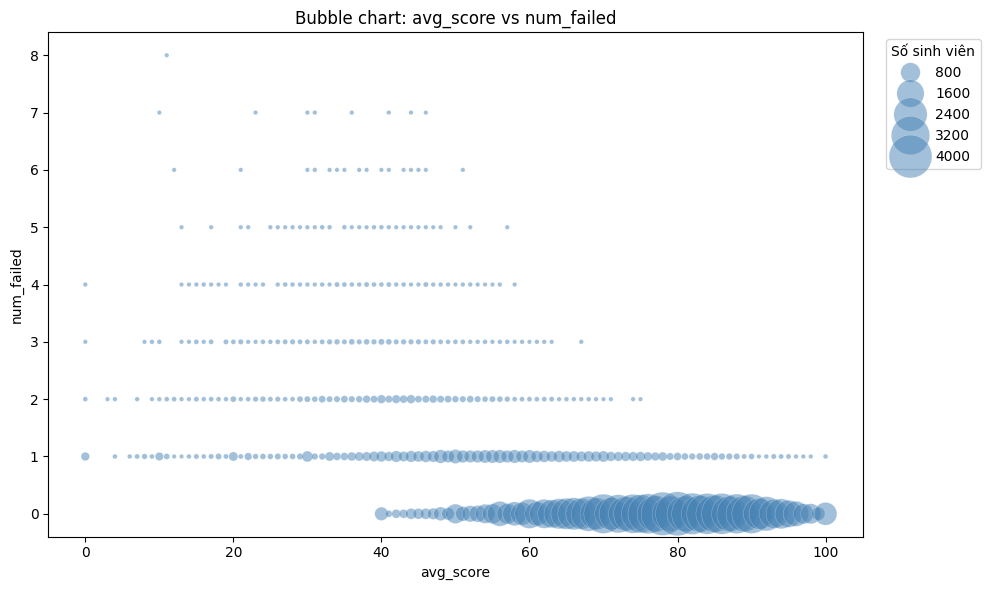

In [54]:
plot_data = (
    dynamic_df
    .assign(avg_score_bin=dynamic_df['avg_score'].round(0))  
    .groupby(['avg_score_bin', 'num_failed'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='avg_score_bin', y='num_failed',
    size='count', sizes=(10, 1000),
    alpha=0.5, color='steelblue', legend='brief',
    data=plot_data
)
plt.xlabel('avg_score')
plt.ylabel('num_failed')
plt.title('Bubble chart: avg_score vs num_failed')
plt.legend(title='Số sinh viên', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [55]:
dynamic_df.groupby('final_result')[dynamic_features].mean()

,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_score,num_failed,avg_days_early
final_result,,,,,,,
Fail,548.590111,11.062361,42.486274,3.076135,63.480067,0.330001,-0.193523
Pass,1377.989576,18.484917,70.236365,4.272566,78.209993,0.088391,1.586727
Withdrawn,542.775431,9.926537,50.106064,2.290006,65.465847,0.270763,-0.912556


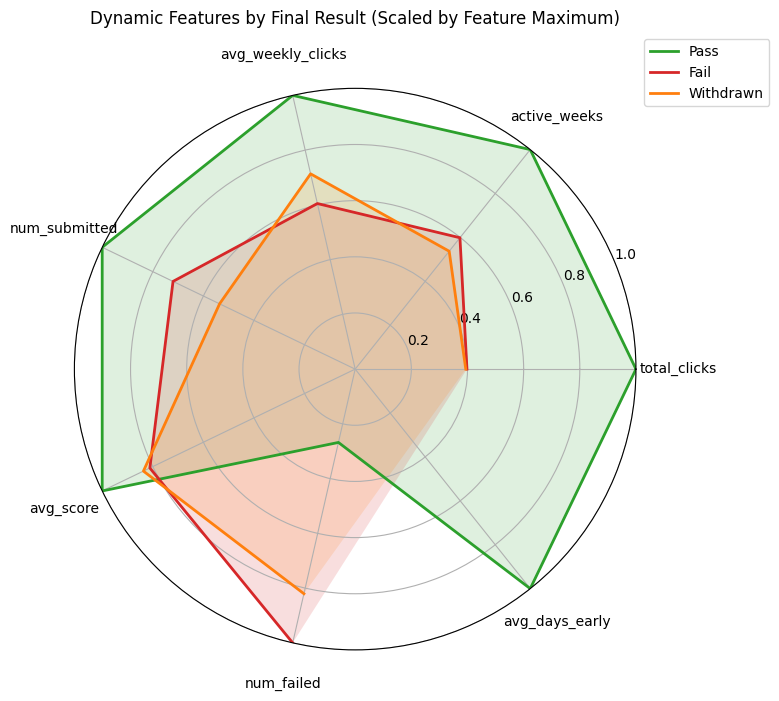

In [56]:
group_means = dynamic_df.groupby('final_result')[dynamic_features].mean()

# Chia mỗi feature cho giá trị lớn nhất của chính feature đó
normalized = group_means / group_means.max()

labels = dynamic_features
num_vars = len(labels)

angles = np.linspace(
    0,
    2 * np.pi,
    num_vars,
    endpoint=False
).tolist()

angles += angles[:1]

colors = {
    'Pass': 'tab:green',
    'Fail': 'tab:red',
    'Withdrawn': 'tab:orange'
}

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for group in ['Pass', 'Fail', 'Withdrawn']:
    values = normalized.loc[group].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=group,
        color=colors[group]
    )

    ax.fill(
        angles,
        values,
        alpha=0.15,
        color=colors[group]
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

for angle, label in zip(angles[:-1], labels):
    ax.text(
        angle,
        1.15,
        label,
        ha='center',
        va='center',
        fontsize=10
    )

ax.set_ylim(0, 1)

ax.set_title(
    'Dynamic Features by Final Result (Scaled by Feature Maximum)',
    y=1.1
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.25, 1.1)
)

plt.tight_layout()
plt.show()

In [58]:
from src.features.build_features import fill_in_weekly_clicks, fill_in_assessment

dynamic_df_filled = fill_in_weekly_clicks(dynamic_df)
dynamic_df_filled = fill_in_assessment(dynamic_df_filled, assessment)

In [60]:
dynamic_df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142384 entries, 0 to 142383
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id_student                 142384 non-null  int64  
 1   code_module                142384 non-null  object 
 2   code_presentation          142384 non-null  object 
 3   prediction_point           142384 non-null  int64  
 4   total_clicks               142384 non-null  float64
 5   active_weeks               142384 non-null  float64
 6   avg_weekly_clicks          142384 non-null  float64
 7   num_submitted              142384 non-null  int64  
 8   avg_score                  127544 non-null  float64
 9   num_failed                 142384 non-null  int64  
 10  avg_days_early             129388 non-null  float64
 11  final_result               142384 non-null  object 
 12  num_due                    142384 non-null  int64  
 13  submission_rate            14

In [61]:
dynamic_df_filled[(dynamic_df_filled['avg_score'].isna()) & (dynamic_df_filled['avg_days_early'].notna())]#['no_submission_despite_due']

,id_student,code_module,code_presentation,prediction_point,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_score,num_failed,avg_days_early,final_result,num_due,submission_rate,no_submission_despite_due
4268,26315,BBB,2014J,30,370.0,7.0,52.857143,1,NaN,1,14.00,Pass,1,1.000000,0
4269,26734,BBB,2014J,30,103.0,7.0,14.714286,1,NaN,0,13.00,Fail,1,1.000000,0
4270,32327,BBB,2014J,30,417.0,5.0,83.400000,1,NaN,1,1.00,Withdrawn,1,1.000000,0
4271,32930,BBB,2014J,30,51.0,2.0,25.500000,1,NaN,1,0.00,Pass,1,1.000000,0
4272,34662,BBB,2014J,30,136.0,7.0,19.428571,1,NaN,1,8.00,Withdrawn,1,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140563,550003,FFF,2014B,240,309.0,7.0,44.142857,2,NaN,0,161.50,Fail,13,0.153846,0
140668,601345,FFF,2014B,240,980.0,8.0,122.500000,7,NaN,0,5.29,Fail,13,0.538462,0
140685,605370,FFF,2014B,240,540.0,8.0,67.500000,1,NaN,0,213.00,Fail,13,0.076923,0
140774,617564,FFF,2014B,240,121.0,4.0,30.250000,1,NaN,0,196.00,Fail,13,0.076923,0


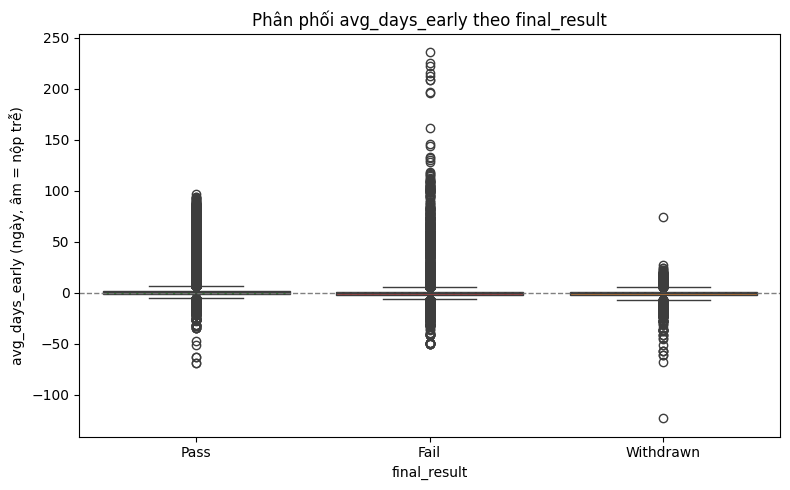

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=dynamic_df, x='final_result', y='avg_days_early',
    order=['Pass', 'Fail', 'Withdrawn'],
    palette={'Pass': 'tab:green', 'Fail': 'tab:red', 'Withdrawn': 'tab:orange'}
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('final_result')
plt.ylabel('avg_days_early (ngày, âm = nộp trễ)')
plt.title('Phân phối avg_days_early theo final_result')
plt.tight_layout()
plt.show()

In [63]:
from pathlib import Path
Path("../data/processed").mkdir(exist_ok=True)
train.to_parquet("../data/processed/train.parquet", index=False)
test.to_parquet("../data/processed/test.parquet", index=False)
print(f"Saved: train {train.shape}, test {test.shape}")

Saved: train (142384, 22), test (35910, 22)
